# 03 - Baseline models: time-series cross-validation
Results from `src/train_baselines.py` (default mode). **Training period only.** The post-gap test set is sealed until the
thresholds in `preregistration.json` are set and committed.

How the CV works: 5 expanding folds. Each fold trains on every cycle before a cutoff and validates on the next 40 cycles,
so the model never sees the future.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
summary = pd.read_csv("../results/m1_cv_summary.csv", index_col=0)
folds = pd.read_csv("../results/m1_cv_folds.csv")
oof = pd.read_csv("../data/processed/m1_cv_predictions.csv")
summary

,mae_mean,mae_std,r2_mean,r2_std
model,,,,
xgboost__set_b_full,6.046,0.578,0.881,0.018
ridge__set_b_full,7.492,0.925,0.802,0.067
ridge__hrv_rhr,9.556,1.049,0.605,0.179
ridge__physiology,9.684,1.156,0.607,0.162
ridge__hrv_only,9.690,1.178,0.604,0.186
xgboost__hrv_rhr,10.162,0.624,0.589,0.128
xgboost__hrv_only,10.256,0.846,0.575,0.176
xgboost__physiology,10.295,0.979,0.594,0.135
ridge__set_b_no_hrv,12.432,1.415,0.527,0.071


## 1. Average error per model (lower is better; bars = spread across folds)

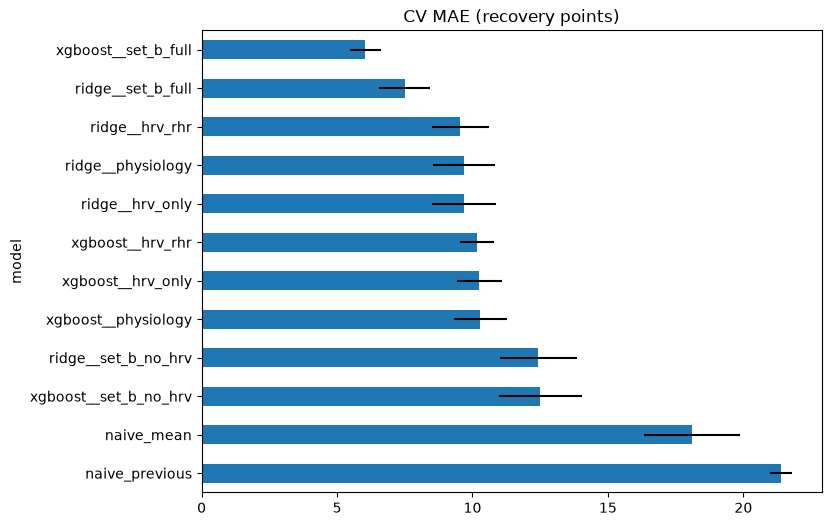

In [2]:
s = summary.sort_values("mae_mean", ascending=False)
s["mae_mean"].plot.barh(xerr=s["mae_std"], figsize=(8, 6), title="CV MAE (recovery points)"); plt.show()

## 2. Tautology check: how much does each block of features add?
Read top to bottom: HRV alone, + RHR, + other physiology, + sleep/load/calendar (= full Set B), and Set B without HRV.

In [3]:
order = ["naive_mean", "xgboost__hrv_only", "xgboost__hrv_rhr", "xgboost__physiology", "xgboost__set_b_full", "xgboost__set_b_no_hrv"]
summary.loc[order, ["mae_mean", "r2_mean"]]

,mae_mean,r2_mean
model,,
naive_mean,18.101,-0.013
xgboost__hrv_only,10.256,0.575
xgboost__hrv_rhr,10.162,0.589
xgboost__physiology,10.295,0.594
xgboost__set_b_full,6.046,0.881
xgboost__set_b_no_hrv,12.502,0.543


## 3. Error per fold over time (is the model stable, or does it drift?)

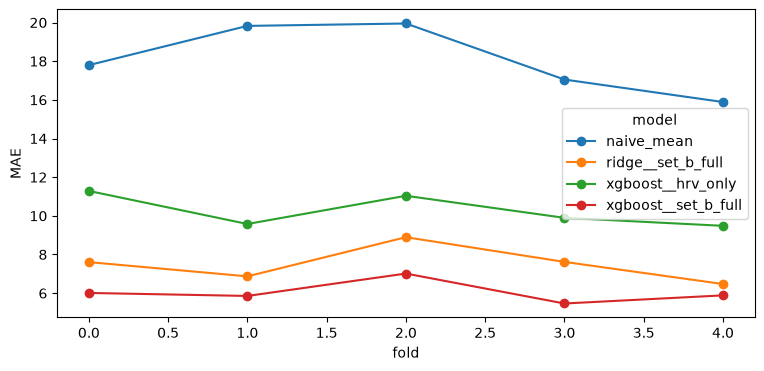

In [4]:
main = ["xgboost__set_b_full", "ridge__set_b_full", "xgboost__hrv_only", "naive_mean"]
folds[folds["model"].isin(main)].pivot(index="fold", columns="model", values="mae").plot(marker="o", figsize=(9, 4))
plt.ylabel("MAE"); plt.show()

## 4. Predicted vs actual (out-of-fold) and where the model misses

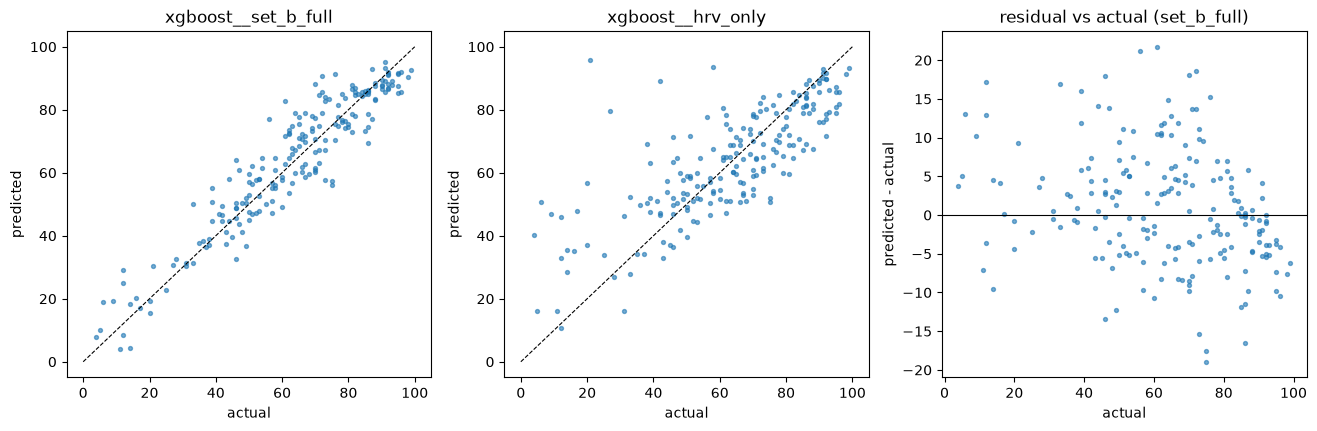

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, m in zip(axes[:2], ["xgboost__set_b_full", "xgboost__hrv_only"]):
    d = oof[oof["model"] == m]
    ax.scatter(d["actual"], d["predicted"], s=8, alpha=0.6); ax.plot([0, 100], [0, 100], "k--", lw=0.8)
    ax.set_title(m); ax.set_xlabel("actual"); ax.set_ylabel("predicted")
d = oof[oof["model"] == "xgboost__set_b_full"]
axes[2].scatter(d["actual"], d["predicted"] - d["actual"], s=8, alpha=0.6); axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_title("residual vs actual (set_b_full)"); axes[2].set_xlabel("actual"); axes[2].set_ylabel("predicted - actual")
plt.show()

## 5. Held-out test
Not run yet. See `preregistration.json`.